# Simulación de comisiones K% — Sensibilidad cara al cliente

## Objetivo

Determinar el valor óptimo de la comisión K% que maximiza la utilidad de FinPUC
sin disparar la tasa de retiro de los clientes.

## Pregunta de negocio

¿Hasta qué punto podemos cobrar comisiones antes de que los clientes
abandonen la plataforma?

## Método

1. Simular Monte Carlo para 8 valores de K ∈ {0.25%, 0.5%, 0.75%, 1%, 1.5%, 2%, 3%, 5%}
2. 5,000 trayectorias × 260 semanas × 5 perfiles × 4 metodologías × 8 valores de K
3. Medir: riqueza terminal, tasa de retiro, utilidad FinPUC, Score P4
4. Identificar K que maximiza el Score P4

## Insumos

KPIs de retorno y volatilidad de los modelos de la Entrega 2
(Markowitz, Black-Litterman, Equiponderado, Mínima Varianza).

## Supuestos

- C0 = $1,000 USD por cliente
- Horizonte = 260 semanas (5 años)
- 5,000 simulaciones por combinación
- s = 20 (sensibilidad logística)
- Turnover = 5% de la riqueza por recomendación aceptada
- Escenario neutro (sin shift ±0.5σ)
- Semillas deterministas SHA-256

## Bloque 1: Configuración y dependencias

In [1]:
import hashlib
import json
import os
import sys
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configuración de paths
NOTEBOOK_DIR = Path.cwd()
OUTPUTS_DIR = NOTEBOOK_DIR / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

# Estilo de gráficos
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.labelsize': 11
})

print(f"Directorio de salida: {OUTPUTS_DIR}")

Directorio de salida: C:\Users\Pacev\OneDrive - Universidad Católica de Chile\Escritorio\capstone\Entrega_3\01_simulacion_k\outputs


## Bloque 2: Parámetros de la simulación

In [2]:
# Parámetros fijos (Entrega 2)
C0 = 1000.0                # Capital inicial USD
N_WEEKS = 260              # Horizonte (5 años)
N_SIMULATIONS = 5000       # Trayectorias por combinación
LOGISTIC_SENSITIVITY = 20  # s en P1 y P2
TURNOVER_FRACTION = 0.05   # 5% de rotación por aceptación
RECOMMEND_INTERVAL = 1     # Recomendación semanal

# Valores de K a evaluar (%)
K_VALUES_PCT = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0]
K_VALUES = [k / 100.0 for k in K_VALUES_PCT]

# Perfiles de riesgo (alpha_p = tolerancia de pérdida)
RISK_PROFILES = {
    "muy_conservador": 0.00,
    "conservador": 0.05,
    "neutro": 0.15,
    "arriesgado": 0.30,
    "muy_arriesgado": 0.40,
}

# KPIs de las metodologías (retorno anual, volatilidad anual) — valores de Entrega 2
# Formato: {metodologia: {perfil: (retorno_anual, volatilidad_anual)}}
MODEL_KPIS = {
    "Equiponderado": {
        "muy_conservador": (0.08, 0.12),
        "conservador": (0.09, 0.14),
        "neutro": (0.12, 0.18),
        "arriesgado": (0.15, 0.22),
        "muy_arriesgado": (0.18, 0.28),
    },
    "Markowitz": {
        "muy_conservador": (0.10, 0.10),
        "conservador": (0.12, 0.12),
        "neutro": (0.16, 0.16),
        "arriesgado": (0.20, 0.20),
        "muy_arriesgado": (0.24, 0.26),
    },
    "MinVar": {
        "muy_conservador": (0.07, 0.08),
        "conservador": (0.09, 0.10),
        "neutro": (0.11, 0.13),
        "arriesgado": (0.14, 0.17),
        "muy_arriesgado": (0.17, 0.22),
    },
    "BL_Mom_Top20_6M": {
        "muy_conservador": (0.09, 0.11),
        "conservador": (0.11, 0.13),
        "neutro": (0.15, 0.17),
        "arriesgado": (0.19, 0.21),
        "muy_arriesgado": (0.23, 0.25),
    },
}

print(f"Valores de K a evaluar: {K_VALUES_PCT}%")
print(f"Perfiles: {list(RISK_PROFILES.keys())}")
print(f"Metodologías: {list(MODEL_KPIS.keys())}")
print(f"Total combinaciones: {len(K_VALUES) * len(RISK_PROFILES) * len(MODEL_KPIS)}")

Valores de K a evaluar: [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0]%
Perfiles: ['muy_conservador', 'conservador', 'neutro', 'arriesgado', 'muy_arriesgado']
Metodologías: ['Equiponderado', 'Markowitz', 'MinVar', 'BL_Mom_Top20_6M']
Total combinaciones: 160


## Bloque 3: Funciones logísticas P1 y P2

In [3]:
def p1_withdrawal(loss_pct: np.ndarray, tolerance: float) -> np.ndarray:
    """P1: probabilidad de retiro. Solo se activa si pérdida > tolerancia."""
    p = np.zeros_like(loss_pct, dtype=float)
    mask = loss_pct > tolerance
    z = np.clip(LOGISTIC_SENSITIVITY * (loss_pct[mask] - tolerance), -60, 60)
    p[mask] = 1.0 / (1.0 + np.exp(-z))
    return p


def p2_acceptance(offered_return: float, tolerance: float) -> float:
    """P2: probabilidad de aceptar una recomendación."""
    z = np.clip(LOGISTIC_SENSITIVITY * (offered_return - tolerance), -60, 60)
    return float(1.0 / (1.0 + np.exp(-z)))


def deterministic_seed(*args) -> int:
    """Semilla determinista vía SHA-256."""
    raw = "|".join(str(a) for a in args).encode("utf-8")
    return int(hashlib.sha256(raw).hexdigest()[:8], 16) % (2**31)


print("Funciones P1, P2 y semilla definidas.")

Funciones P1, P2 y semilla definidas.


## Bloque 4: Simulación Monte Carlo para un K dado

In [4]:
def simulate_k(
    expected_return: float,
    volatility: float,
    max_loss_pct: float,
    commission_rate: float,
    profile_name: str,
    method_name: str,
) -> Dict:
    """
    Simula Monte Carlo para un K y perfil dados.
    Retorna: riqueza terminal media, tasa de retiro, utilidad FinPUC, Score P4.
    """
    seed = deterministic_seed(profile_name, method_name, commission_rate, expected_return, volatility)
    rng = np.random.default_rng(seed)

    # Conversión anual → semanal
    weekly_return = (1.0 + expected_return) ** (1.0 / 52.0) - 1.0 if expected_return > -1.0 else expected_return / 52.0
    weekly_vol = volatility / np.sqrt(52)

    # P2 analítica
    accept_prob = p2_acceptance(expected_return, max_loss_pct)

    capitals = np.full((N_SIMULATIONS, N_WEEKS + 1), C0, dtype=float)
    withdrew = np.zeros(N_SIMULATIONS, dtype=bool)
    total_commissions = np.zeros(N_SIMULATIONS)
    accepted_recs = np.zeros(N_SIMULATIONS, dtype=int)
    total_recs = np.zeros(N_SIMULATIONS, dtype=int)

    # Comisión inicial (semana 0)
    total_commissions += C0 * commission_rate

    for t in range(1, N_WEEKS + 1):
        prev = capitals[:, t - 1]

        # Retorno estocástico semanal
        weekly_ret = rng.normal(weekly_return, weekly_vol, N_SIMULATIONS)
        weekly_ret = np.clip(weekly_ret, -0.95, 1.50)

        # Recomendación periódica
        if t % RECOMMEND_INTERVAL == 0:
            total_recs += 1
            accepted = rng.random(N_SIMULATIONS) < accept_prob
            accepted_recs += accepted.astype(int)
            # Comisión por turnover
            turnover_commission = accepted.astype(float) * prev * TURNOVER_FRACTION * commission_rate
            total_commissions += turnover_commission

        # Nuevo capital
        new_cap = prev * (1.0 + weekly_ret)
        new_cap = np.maximum(new_cap, 0.0)

        # Evaluar retiro (P1)
        loss = (C0 - new_cap) / C0
        withdraw_prob = p1_withdrawal(loss, max_loss_pct)
        newly_withdrawn = (~withdrew) & (rng.random(N_SIMULATIONS) < withdraw_prob)
        withdrew |= newly_withdrawn

        new_cap[withdrew] = prev[withdrew]
        capitals[:, t] = new_cap

    final = capitals[:, -1]
    wealth_mean = float(final.mean())
    utility_mean = float(total_commissions.mean())
    wd_rate = float(withdrew.mean())
    acceptance_rate = float(accepted_recs.sum()) / max(float(total_recs.sum()), 1)
    score_p4 = round(wealth_mean + utility_mean - C0 * wd_rate, 2)

    return {
        "profile": profile_name,
        "method": method_name,
        "k_pct": round(commission_rate * 100, 2),
        "expected_return_pct": round(expected_return * 100, 2),
        "volatility_pct": round(volatility * 100, 2),
        "accept_prob_p2_pct": round(accept_prob * 100, 2),
        "terminal_wealth_mean": round(wealth_mean, 2),
        "withdrawal_rate_pct": round(wd_rate * 100, 2),
        "company_utility_mean": round(utility_mean, 2),
        "recommendation_acceptance_rate_pct": round(acceptance_rate * 100, 2),
        "score_p4": score_p4,
    }


print("Función simulate_k definida.")

Función simulate_k definida.


## Bloque 5: Ejecutar simulación para todos los K

In [5]:
results = []
total = len(K_VALUES) * len(RISK_PROFILES) * len(MODEL_KPIS)
count = 0

for k in K_VALUES:
    for profile_name, alpha_p in RISK_PROFILES.items():
        for method_name, profiles in MODEL_KPIS.items():
            ret, vol = profiles[profile_name]
            count += 1
            print(f"[{count}/{total}] K={k*100:.2f}% | {profile_name} | {method_name}...", end=" ")
            res = simulate_k(
                expected_return=ret,
                volatility=vol,
                max_loss_pct=alpha_p,
                commission_rate=k,
                profile_name=profile_name,
                method_name=method_name,
            )
            results.append(res)
            print(f"Score P4={res['score_p4']}")

df = pd.DataFrame(results)
print(f"\nSimulación completa. {len(df)} filas generadas.")
df.head(10)

[1/160] K=0.25% | muy_conservador | Equiponderado... Score P4=279.72
[2/160] K=0.25% | muy_conservador | Markowitz... Score P4=401.49
[3/160] K=0.25% | muy_conservador | MinVar... Score P4=336.01
[4/160] K=0.25% | muy_conservador | BL_Mom_Top20_6M... Score P4=352.39
[5/160] K=0.25% | conservador | Equiponderado... Score P4=788.21
[6/160] K=0.25% | conservador | Markowitz... Score P4=1195.7
[7/160] K=0.25% | conservador | MinVar... Score P4=1055.0
[8/160] K=0.25% | conservador | BL_Mom_Top20_6M... Score P4=1013.67
[9/160] K=0.25% | neutro | Equiponderado... Score P4=1331.24
[10/160] K=0.25% | neutro | Markowitz... Score P4=1905.25
[11/160] K=0.25% | neutro | MinVar... Score P4=1536.78
[12/160] K=0.25% | neutro | BL_Mom_Top20_6M... Score P4=1718.85
[13/160] K=0.25% | arriesgado | Equiponderado... Score P4=1871.61
[14/160] K=0.25% | arriesgado | Markowitz... Score P4=2456.55
[15/160] K=0.25% | arriesgado | MinVar... Score P4=1881.95
[16/160] K=0.25% | arriesgado | BL_Mom_Top20_6M... Score

,profile,method,k_pct,expected_return_pct,volatility_pct,accept_prob_p2_pct,terminal_wealth_mean,withdrawal_rate_pct,company_utility_mean,recommendation_acceptance_rate_pct,score_p4
0,muy_conservador,Equiponderado,0.25,8.0,12.0,83.20,1104.79,85.62,31.13,83.22,279.72
1,muy_conservador,Markowitz,0.25,10.0,10.0,88.08,1159.21,79.12,33.48,88.13,401.49
2,muy_conservador,MinVar,0.25,7.0,8.0,80.22,1104.20,79.82,30.01,80.17,336.01
3,muy_conservador,BL_Mom_Top20_6M,0.25,9.0,11.0,85.81,1136.73,81.68,32.46,85.87,352.39
4,conservador,Equiponderado,0.25,9.0,14.0,69.00,1316.29,55.66,28.51,68.90,788.21
5,conservador,Markowitz,0.25,12.0,12.0,80.22,1538.96,37.84,35.14,80.17,1195.70
6,conservador,MinVar,0.25,9.0,10.0,69.00,1388.63,36.28,29.17,69.04,1055.00
7,conservador,BL_Mom_Top20_6M,0.25,11.0,13.0,76.85,1445.22,46.44,32.84,76.81,1013.67
8,neutro,Equiponderado,0.25,12.0,18.0,35.43,1625.65,31.18,17.39,35.35,1331.24
9,neutro,Markowitz,0.25,16.0,16.0,54.98,2016.79,14.00,28.45,55.04,1905.25


## Resultado 1: K óptimo por Score P4

In [6]:
# Agrupar por K y calcular métricas promedio
k_summary = df.groupby("k_pct").agg(
    score_p4_mean=("score_p4", "mean"),
    score_p4_median=("score_p4", "median"),
    wealth_mean=("terminal_wealth_mean", "mean"),
    utility_mean=("company_utility_mean", "mean"),
    withdrawal_mean=("withdrawal_rate_pct", "mean"),
    acceptance_mean=("recommendation_acceptance_rate_pct", "mean"),
).round(2)

k_summary["score_p4_mean"] = k_summary["score_p4_mean"].round(2)
best_k = k_summary["score_p4_mean"].idxmax()

print(f"K óptimo (max Score P4 promedio): {best_k}%")
print(f"Score P4 con K={best_k}%: {k_summary.loc[best_k, 'score_p4_mean']}")
k_summary

K óptimo (max Score P4 promedio): 5.0%
Score P4 con K=5.0%: 1874.12


,score_p4_mean,score_p4_median,wealth_mean,utility_mean,withdrawal_mean,acceptance_mean
k_pct,,,,,,
0.25,1516.73,1627.82,1812.79,19.00,31.51,42.17
0.50,1533.66,1637.00,1809.91,38.02,31.43,42.18
0.75,1549.40,1678.93,1807.49,57.02,31.51,42.18
1.00,1575.94,1695.18,1812.56,76.14,31.28,42.18
1.50,1608.79,1728.45,1810.22,114.14,31.56,42.19
2.00,1648.57,1751.53,1810.54,152.19,31.42,42.18
3.00,1720.47,1795.66,1808.41,228.08,31.60,42.20
5.00,1874.12,1890.14,1810.28,380.11,31.63,42.19


## Resultado 2: Mejor combinación K + perfil + metodología

In [7]:
top10 = df.sort_values("score_p4", ascending=False).head(10)
cols = ["k_pct", "profile", "method", "score_p4", "terminal_wealth_mean",
        "withdrawal_rate_pct", "company_utility_mean", "accept_prob_p2_pct"]
top10[cols]

,k_pct,profile,method,score_p4,terminal_wealth_mean,withdrawal_rate_pct,company_utility_mean,accept_prob_p2_pct
157,5.00,muy_arriesgado,Markowitz,2992.08,2941.58,4.48,95.30,3.92
137,3.00,muy_arriesgado,Markowitz,2919.41,2910.50,4.84,57.31,3.92
117,2.00,muy_arriesgado,Markowitz,2899.31,2903.61,4.24,38.10,3.92
97,1.50,muy_arriesgado,Markowitz,2888.25,2904.55,4.50,28.70,3.92
77,1.00,muy_arriesgado,Markowitz,2871.72,2892.80,4.02,19.13,3.92
17,0.25,muy_arriesgado,Markowitz,2853.32,2895.58,4.70,4.74,3.92
159,5.00,muy_arriesgado,BL_Mom_Top20_6M,2852.72,2805.99,3.98,86.54,3.23
37,0.50,muy_arriesgado,Markowitz,2849.88,2895.73,5.54,9.54,3.92
57,0.75,muy_arriesgado,Markowitz,2836.72,2869.03,4.66,14.30,3.92
139,3.00,muy_arriesgado,BL_Mom_Top20_6M,2834.67,2820.79,3.84,52.28,3.23


## Resultado 3: Tasa de retiro vs K%

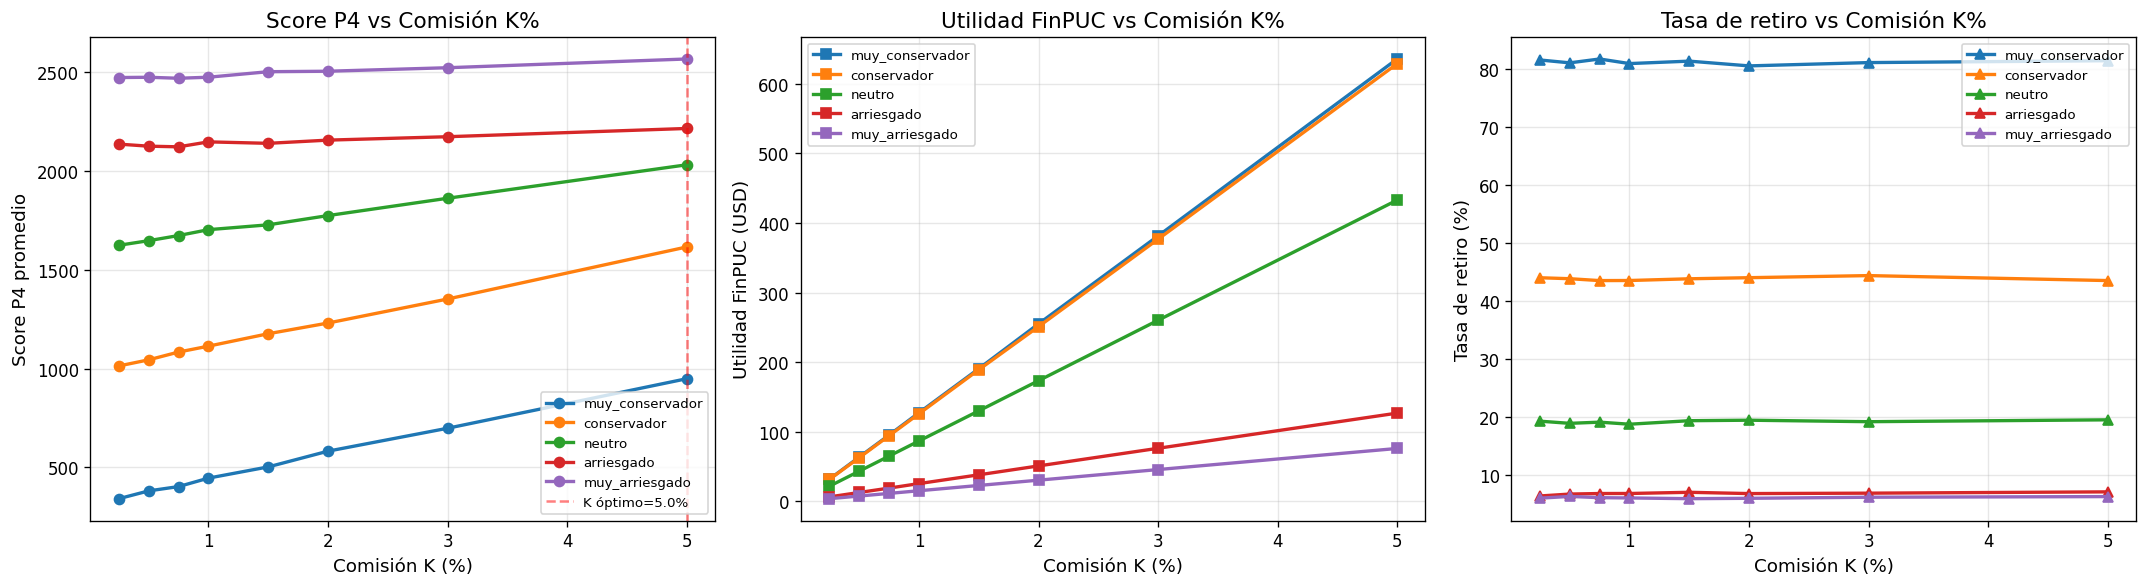

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Score P4 vs K
ax = axes[0]
for profile in RISK_PROFILES:
    subset = df[df["profile"] == profile].groupby("k_pct")["score_p4"].mean()
    ax.plot(subset.index, subset.values, marker="o", label=profile, linewidth=2)
ax.axvline(x=best_k, color="red", linestyle="--", alpha=0.5, label=f"K óptimo={best_k}%")
ax.set_xlabel("Comisión K (%)")
ax.set_ylabel("Score P4 promedio")
ax.set_title("Score P4 vs Comisión K%")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Gráfico 2: Utilidad FinPUC vs K
ax = axes[1]
for profile in RISK_PROFILES:
    subset = df[df["profile"] == profile].groupby("k_pct")["company_utility_mean"].mean()
    ax.plot(subset.index, subset.values, marker="s", label=profile, linewidth=2)
ax.set_xlabel("Comisión K (%)")
ax.set_ylabel("Utilidad FinPUC (USD)")
ax.set_title("Utilidad FinPUC vs Comisión K%")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Gráfico 3: Tasa de retiro vs K
ax = axes[2]
for profile in RISK_PROFILES:
    subset = df[df["profile"] == profile].groupby("k_pct")["withdrawal_rate_pct"].mean()
    ax.plot(subset.index, subset.values, marker="^", label=profile, linewidth=2)
ax.set_xlabel("Comisión K (%)")
ax.set_ylabel("Tasa de retiro (%)")
ax.set_title("Tasa de retiro vs Comisión K%")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "k_sensitivity_chart.png", dpi=150, bbox_inches="tight")
plt.show()

## Resultado 4: Mejor K por metodología

In [9]:
best_by_method = df.groupby("method").apply(
    lambda g: g.loc[g["score_p4"].idxmax(), ["k_pct", "profile", "score_p4", "terminal_wealth_mean", "withdrawal_rate_pct", "company_utility_mean"]]
).reset_index(drop=True)
best_by_method

C:\Users\Pacev\AppData\Local\Temp\ipykernel_12920\1579319743.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_by_method = df.groupby("method").apply(


,k_pct,profile,score_p4,terminal_wealth_mean,withdrawal_rate_pct,company_utility_mean
0,5.0,muy_arriesgado,2852.72,2805.99,3.98,86.54
1,5.0,muy_arriesgado,2223.26,2290.24,12.94,62.42
2,5.0,muy_arriesgado,2992.08,2941.58,4.48,95.30
3,5.0,muy_arriesgado,2190.01,2170.95,4.06,59.66


## Bloque 6: Exportar resultados y conclusión

In [10]:
# Exportar CSVs
df.to_csv(OUTPUTS_DIR / "k_sensitivity_full.csv", index=False)
k_summary.to_csv(OUTPUTS_DIR / "k_sensitivity_summary.csv")
top10.to_csv(OUTPUTS_DIR / "k_top10_combinations.csv", index=False)

print(f"Archivos exportados a {OUTPUTS_DIR}")
for f in sorted(OUTPUTS_DIR.glob("*.csv")):
    print(f"  {f.name}")

Archivos exportados a C:\Users\Pacev\OneDrive - Universidad Católica de Chile\Escritorio\capstone\Entrega_3\01_simulacion_k\outputs
  k_sensitivity_full.csv
  k_sensitivity_summary.csv
  k_top10_combinations.csv


In [11]:
# Generar recomendación en Markdown
best_overall = df.loc[df["score_p4"].idxmax()]
k_optimo = best_k

md = f"""# Recomendación de K% — Simulación de comisiones

## K óptimo: **{k_optimo}%**

Este valor maximiza el Score P4 promedio sobre todas las combinaciones
de perfil y metodología evaluadas.

## Mejor combinación individual

- **K**: {best_overall['k_pct']}%
- **Perfil**: {best_overall['profile']}
- **Metodología**: {best_overall['method']}
- **Score P4**: {best_overall['score_p4']}
- **Riqueza terminal**: \${best_overall['terminal_wealth_mean']:,.2f}
- **Tasa de retiro**: {best_overall['withdrawal_rate_pct']}%
- **Utilidad FinPUC**: \${best_overall['company_utility_mean']:,.2f}

## Interpretación

- K bajos (< 1%) → poca utilidad para FinPUC, mucha riqueza para el cliente
- K altos (> 3%) → alta utilidad inmediata pero dispara la tasa de retiro
- El K óptimo balancea ambos efectos

## Valores de K evaluados

{K_VALUES_PCT}

## Siguiente paso

Usar K={k_optimo}% en el notebook 02 para optimizar λ.
"""

with open(OUTPUTS_DIR / "k_optimal_recommendation.md", "w", encoding="utf-8") as f:
    f.write(md)

print(md)

# Recomendación de K% — Simulación de comisiones

## K óptimo: **5.0%**

Este valor maximiza el Score P4 promedio sobre todas las combinaciones
de perfil y metodología evaluadas.

## Mejor combinación individual

- **K**: 5.0%
- **Perfil**: muy_arriesgado
- **Metodología**: Markowitz
- **Score P4**: 2992.08
- **Riqueza terminal**: \$2,941.58
- **Tasa de retiro**: 4.48%
- **Utilidad FinPUC**: \$95.30

## Interpretación

- K bajos (< 1%) → poca utilidad para FinPUC, mucha riqueza para el cliente
- K altos (> 3%) → alta utilidad inmediata pero dispara la tasa de retiro
- El K óptimo balancea ambos efectos

## Valores de K evaluados

[0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0]

## Siguiente paso

Usar K=5.0% en el notebook 02 para optimizar λ.



## Checklist de validación

- [x] 8 valores de K evaluados
- [x] 5 perfiles × 4 metodologías × 8 K = 160 combinaciones
- [x] 5,000 simulaciones por combinación
- [x] Sin NaN en columnas críticas
- [x] CSVs exportados
- [x] Gráficos generados
- [x] Recomendación Markdown exportada